# Data Loading

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.detector.data import (
    build_grouped_volume_registry,
    load_e2e_volume,
    select_bscan,
)

E2E_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "heyex"
    / "meta"
)

registry = build_grouped_volume_registry(
    e2e_directory=E2E_DIRECTORY,
    progression_groups={
        "fast": [8, 9, 12, 41, 49],
        "slow": [17, 23, 35, 36, 47],
    },
)

record = registry[0]

volume = load_e2e_volume(
    record.e2e_path
)

bscan_index, bscan = select_bscan(
    volume,
    selection="center",
)

print("Subject:", record.subject_id)
print("Group:", record.progression_group)
print("Volume shape:", volume.shape)
print("Selected B-scan:", bscan_index)
print("B-scan shape:", bscan.shape)

Subject: 8
Group: fast
Volume shape: (97, 496, 512)
Selected B-scan: 48
B-scan shape: (496, 512)


# Preprocessing

In [2]:
from src.detector.preprocessing import (
    preprocess_bscan,
)

# --------------------------------------------------
# Preprocessing configuration
# --------------------------------------------------

PREPROCESSING_CONFIG = {
    "layer_name": "BM",

    # Flattening
    "reference_row": None,
    "flatten_fill_value": 0.0,

    # Crop
    "depth_below_layer": 150,
    "include_boundary": True,
    "require_full_depth": False,
    "crop_fill_value": 0.0,

    # Normalization
    "normalization_method": "zscore",
    "lower_percentile": 1.0,
    "upper_percentile": 99.0,

    # Denoising
    "denoise_method": "gaussian",
    "gaussian_sigma": (1.0, 0.5),
}

# --------------------------------------------------
# Run preprocessing
# --------------------------------------------------

result = preprocess_bscan(
    volume=volume,
    bscan_index=bscan_index,
    **PREPROCESSING_CONFIG,
)

print("Completed preprocessing.")
print(result)

Completed preprocessing.
PreprocessedScan(bscan_index=48, layer_name='BM', raw_bscan=array([[0., 0., 0., ..., 0., 0., 0.],
       [3., 0., 0., ..., 0., 1., 0.],
       [4., 0., 0., ..., 4., 2., 0.],
       ...,
       [0., 1., 6., ..., 0., 0., 0.],
       [0., 1., 5., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(496, 512), dtype=float32), layer_boundary=array([222.61269, 222.87262, 223.13268, 223.393  , 223.65387, 223.91563,
       224.17873, 224.44365, 224.71101, 224.98146, 225.25568, 225.53435,
       225.81812, 226.10757, 226.40327, 226.70561, 227.01497, 227.33163,
       227.65582, 227.9876 , 228.32697, 228.67381, 229.02792, 229.389  ,
       229.75667, 230.13048, 230.5099 , 230.89444, 231.2835 , 231.67651,
       232.0729 , 232.4721 , 232.87354, 233.2767 , 233.68106, 234.08612,
       234.49135, 234.89624, 235.30025, 235.7028 , 236.10336, 236.50136,
       236.89624, 237.28749, 237.67462, 238.05722, 238.43488, 238.80728,
       239.17422, 239.53555, 239.89125, 2

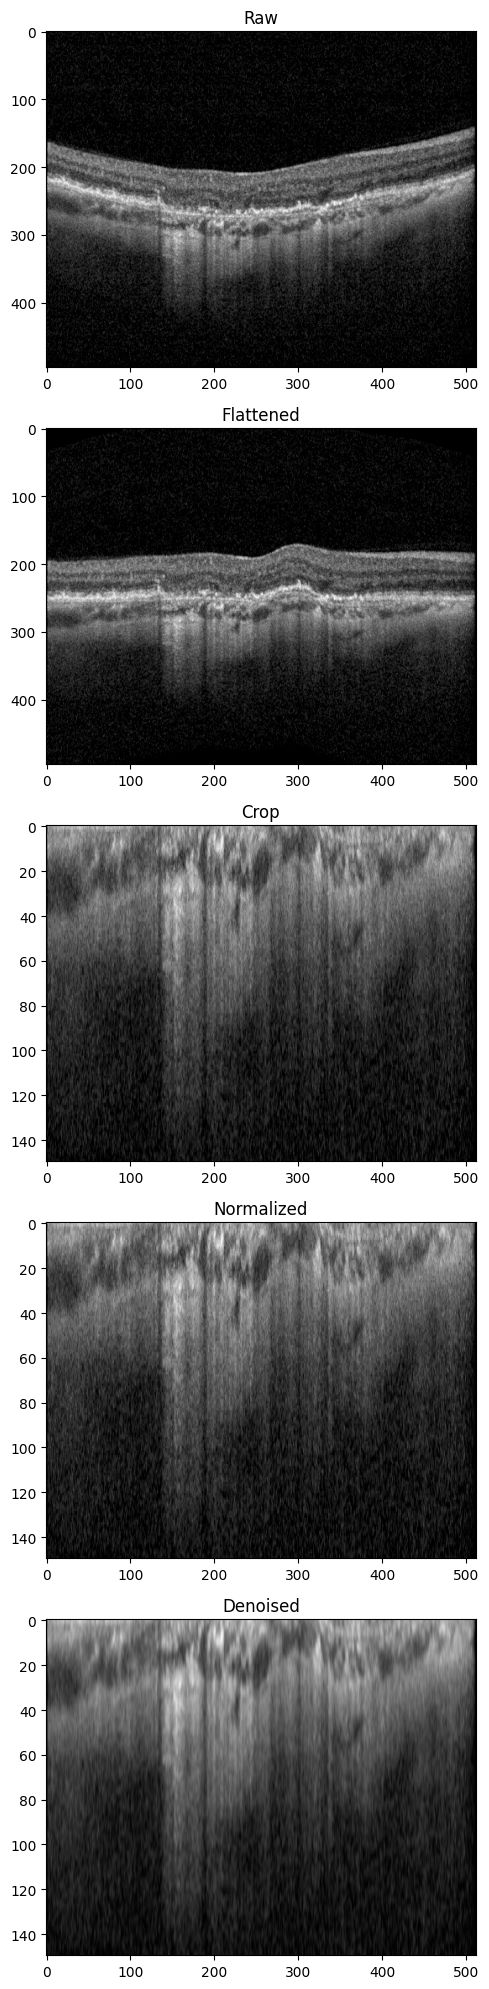

In [3]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(5,20),
)

axes[0].imshow(
    result.raw_bscan,
    cmap="gray",
    aspect="auto",
)
axes[0].set_title("Raw")

axes[1].imshow(
    result.flattened_bscan,
    cmap="gray",
    aspect="auto",
)
axes[1].set_title("Flattened")

axes[2].imshow(
    result.sub_layer_crop,
    cmap="gray",
    aspect="auto",
)
axes[2].set_title("Crop")

axes[3].imshow(
    result.normalized_scan,
    cmap="gray",
    aspect="auto",
)
axes[3].set_title("Normalized")

axes[4].imshow(
    result.denoised_scan,
    cmap="gray",
    aspect="auto",
)
axes[4].set_title("Denoised")

plt.tight_layout()

In [4]:
from pprint import pprint

pprint(result.metadata)

{'available_layers': ['ILM',
                      'BM',
                      'RNFL',
                      'GCL',
                      'IPL',
                      'INL',
                      'OPL',
                      'ELM',
                      'PR1',
                      'PR2',
                      'RPE'],
 'boundary_maximum': 283.439453125,
 'boundary_median': 255.50411987304688,
 'boundary_minimum': 211.09371948242188,
 'bscan_meta': {'acquisitionTime': '2024-02-16T23:22:37.164000',
                'aktImage': 48,
                'center_x': 0.249420166015625,
                'center_y': -0.15868902206420898,
                'end_pos': (10.255987167358398, 0.16282153129577637),
                'end_x': 10.255987167358398,
                'end_y': 0.16282153129577637,
                'imgSizeWidth': 511,
                'n_bscans': 97,
                'numAve': 0,
                'pos_unit': '°',
                'quality': 0.8416000008583069,
                'scale_y': 0.0

# Feature Extraction

In [5]:
FEATURE_CONFIG = {
    "window_width": 21, #TODO Tune
    "stride": 1, #TODO Tune
    "padding_mode": "reflect",

    "verticality_gradient_sigma": 1.0,
    "verticality_tensor_sigma": 2.0,
    "verticality_summary": "mean",

    "persistence_bright_percentile": 75.0, #TODO Tune
    "persistence_minimum_verticality": 0.20, #TODO Tune
    "persistence_method": "longest_run",
    "persistence_summary": "mean",

    # Depth continuity
    "continuity_depth_lag": 1,
    "continuity_summary": "mean",
    "continuity_minimum_row_standard_deviation": 1e-6,

    "amplitude_statistic": "mean",
    "amplitude_percentile": 90.0,

    "heterogeneity_method": "column_std",

    "standardization_clip_limits": (-5.0, 5.0),
}

In [6]:
from src.detector.features import (
    extract_feature_signals,
)

feature_result = extract_feature_signals(
    image=result.denoised_scan,
    **FEATURE_CONFIG,
)

print("Feature extraction completed.")
print("Image shape:", result.denoised_scan.shape)
print("Number of evaluated positions:", feature_result.x_positions.size)
print(
    "Horizontal range:",
    feature_result.x_positions.min(),
    "to",
    feature_result.x_positions.max(),
)

print("\nRaw feature shapes:")
for feature_name, values in feature_result.raw_features.items():
    print(
        f"  {feature_name}: "
        f"shape={values.shape}, "
        f"min={values.min():.4f}, "
        f"max={values.max():.4f}, "
        f"mean={values.mean():.4f}"
    )

print("\nStandardized feature shapes:")
for feature_name, values in (
    feature_result.standardized_features.items()
):
    print(
        f"  {feature_name}: "
        f"shape={values.shape}, "
        f"min={values.min():.4f}, "
        f"max={values.max():.4f}, "
        f"mean={values.mean():.4f}"
    )

print(
    "\nVerticality map shape:",
    feature_result.verticality_map.shape,
)

print(
    "Persistence signal shape:",
    feature_result.persistence_signal.shape,
)

Feature extraction completed.
Image shape: (150, 512)
Number of evaluated positions: 512
Horizontal range: 0.0 to 511.0

Raw feature shapes:
  verticality: shape=(512,), min=0.1834, max=0.6135, mean=0.3434
  persistence: shape=(512,), min=0.0013, max=0.2324, mean=0.0944
  continuity: shape=(512,), min=0.8362, max=0.9626, mean=0.8955
  amplitude: shape=(512,), min=-0.6458, max=0.6933, mean=0.0016
  heterogeneity: shape=(512,), min=0.0206, max=0.3920, mean=0.1223

Standardized feature shapes:
  verticality: shape=(512,), min=-1.1790, max=2.2788, mean=0.1068
  persistence: shape=(512,), min=-1.0467, max=1.7860, mean=0.0942
  continuity: shape=(512,), min=-1.4810, max=1.7266, mean=0.0220
  amplitude: shape=(512,), min=-2.5357, max=3.4173, mean=0.3422
  heterogeneity: shape=(512,), min=-0.9049, max=3.5994, mean=0.3290

Verticality map shape: (150, 512)
Persistence signal shape: (512,)


In [7]:
feature_dataframe = feature_result.to_dataframe(
    include_standardized=True,
)

print("Feature DataFrame shape:", feature_dataframe.shape)

display(
    feature_dataframe.head(10)
)

Feature DataFrame shape: (512, 11)


,x_position,verticality,persistence,continuity,amplitude,heterogeneity,verticality_standardized,persistence_standardized,continuity_standardized,amplitude_standardized,heterogeneity_standardized
0,0.0,0.561045,0.062222,0.950520,-0.223064,0.285542,1.857021,-0.299611,1.419081,-0.656374,2.308387
1,1.0,0.560261,0.062222,0.950960,-0.222275,0.285837,1.850716,-0.299611,1.430244,-0.652867,2.311971
2,2.0,0.558064,0.061905,0.949977,-0.223383,0.285469,1.833058,-0.303502,1.405296,-0.657790,2.307505
3,3.0,0.554225,0.060952,0.950207,-0.221761,0.286075,1.802192,-0.315175,1.411132,-0.650579,2.314855
4,4.0,0.546968,0.058095,0.949116,-0.221066,0.286366,1.743844,-0.350195,1.383435,-0.647493,2.318378
5,5.0,0.533745,0.054603,0.949063,-0.225298,0.284846,1.637530,-0.392996,1.382089,-0.666305,2.299946
6,6.0,0.513008,0.049841,0.947638,-0.227391,0.284213,1.470812,-0.451362,1.345938,-0.675610,2.292273
7,7.0,0.486235,0.043810,0.945859,-0.226058,0.284912,1.255557,-0.525292,1.300781,-0.669683,2.300754
8,8.0,0.455430,0.038730,0.949591,-0.225574,0.285176,1.007890,-0.587549,1.395505,-0.667534,2.303955
9,9.0,0.422252,0.033651,0.950259,-0.221139,0.287204,0.741151,-0.649805,1.412457,-0.647814,2.328545


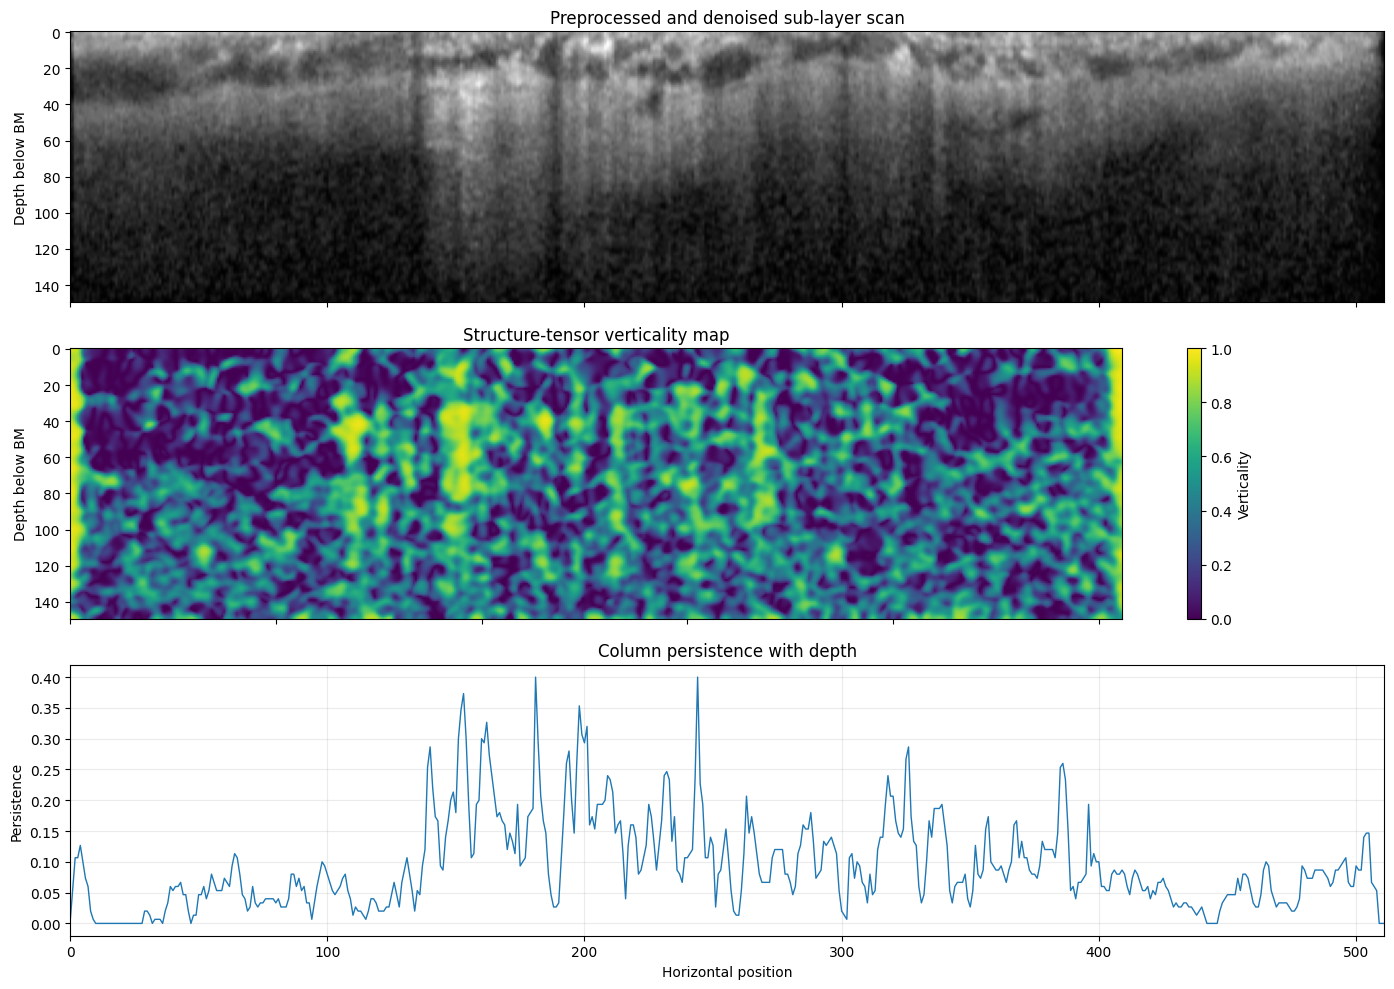

In [8]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True,
)

axes[0].imshow(
    result.denoised_scan,
    cmap="gray",
    aspect="auto",
)

axes[0].set_title(
    "Preprocessed and denoised sub-layer scan"
)
axes[0].set_ylabel(
    "Depth below BM"
)

verticality_image = axes[1].imshow(
    feature_result.verticality_map,
    cmap="viridis",
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

axes[1].set_title(
    "Structure-tensor verticality map"
)
axes[1].set_ylabel(
    "Depth below BM"
)

fig.colorbar(
    verticality_image,
    ax=axes[1],
    label="Verticality",
)

axes[2].plot(
    np.arange(
        feature_result.persistence_signal.size
    ),
    feature_result.persistence_signal,
    linewidth=1.0,
)

axes[2].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)
axes[2].set_title(
    "Column persistence with depth"
)
axes[2].set_xlabel(
    "Horizontal position"
)
axes[2].set_ylabel(
    "Persistence"
)
axes[2].grid(
    alpha=0.25,
)

plt.tight_layout()
plt.show()

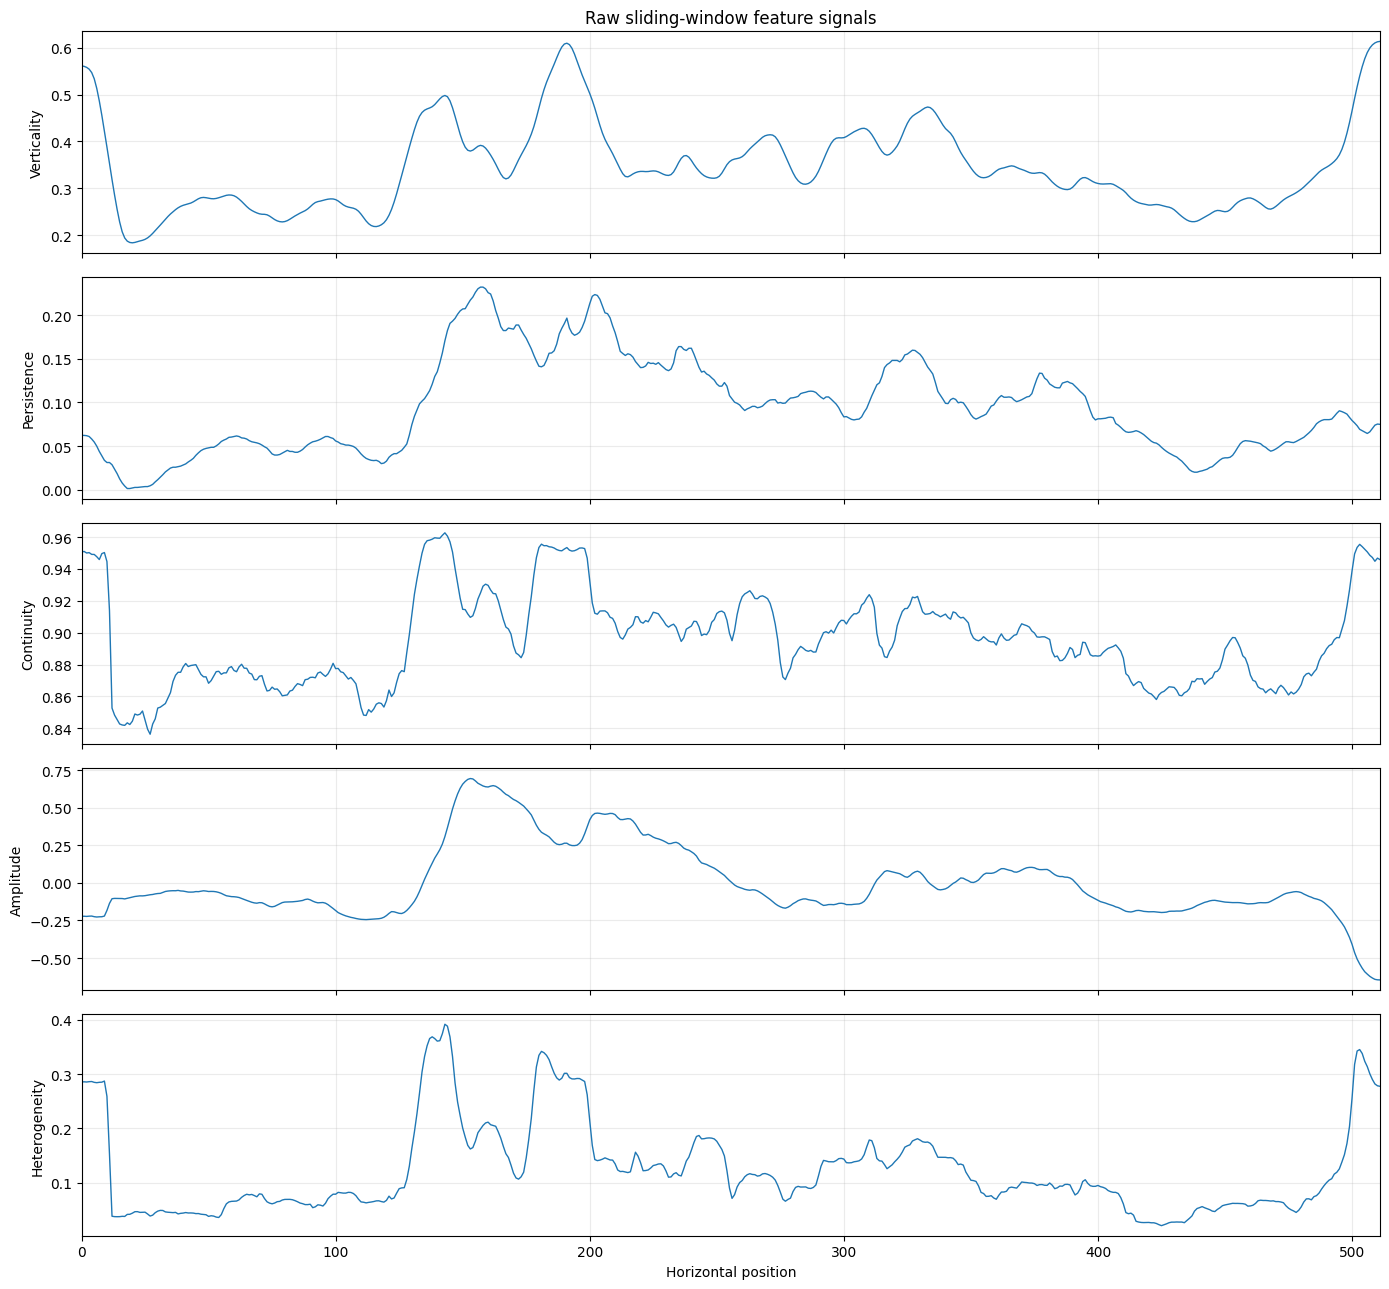

In [9]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 13),
    sharex=True,
)

for axis, feature_name in zip(
    axes,
    (
        "verticality",
        "persistence",
        "continuity",
        "amplitude",
        "heterogeneity",
    ),
):
    axis.plot(
        feature_result.x_positions,
        feature_result.raw_features[
            feature_name
        ],
        linewidth=1.0,
    )

    axis.set_ylabel(
        feature_name.title()
    )

    axis.grid(
        alpha=0.25,
    )

axes[0].set_title(
    "Raw sliding-window feature signals"
)

axes[-1].set_xlabel(
    "Horizontal position"
)

axes[-1].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

plt.tight_layout()
plt.show()

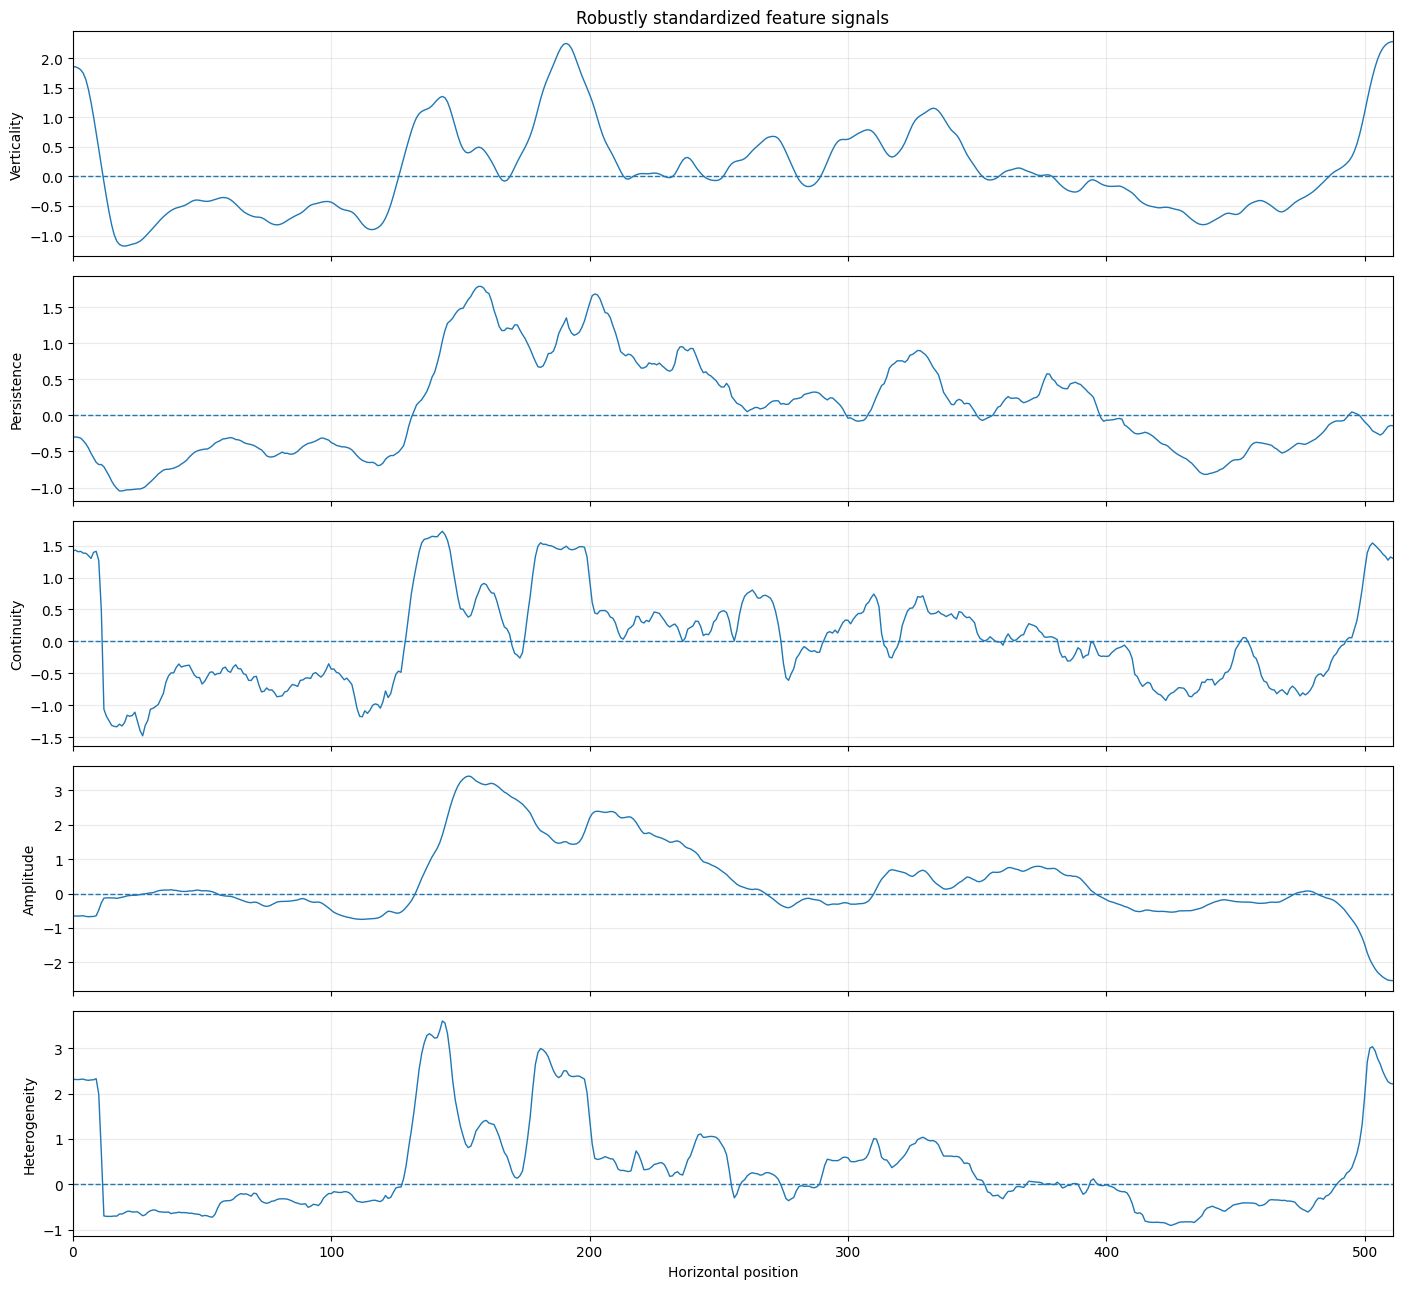

In [10]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 13),
    sharex=True,
)

for axis, feature_name in zip(
    axes,
    (
        "verticality",
        "persistence",
        "continuity",
        "amplitude",
        "heterogeneity",
    ),
):
    axis.plot(
        feature_result.x_positions,
        feature_result.standardized_features[
            feature_name
        ],
        linewidth=1.0,
    )

    axis.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )

    axis.set_ylabel(
        feature_name.title()
    )

    axis.grid(
        alpha=0.25,
    )

axes[0].set_title(
    "Robustly standardized feature signals"
)

axes[-1].set_xlabel(
    "Horizontal position"
)

axes[-1].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

plt.tight_layout()
plt.show()

In [11]:
# Install once if necessary:
# %pip install ipympl

%matplotlib widget

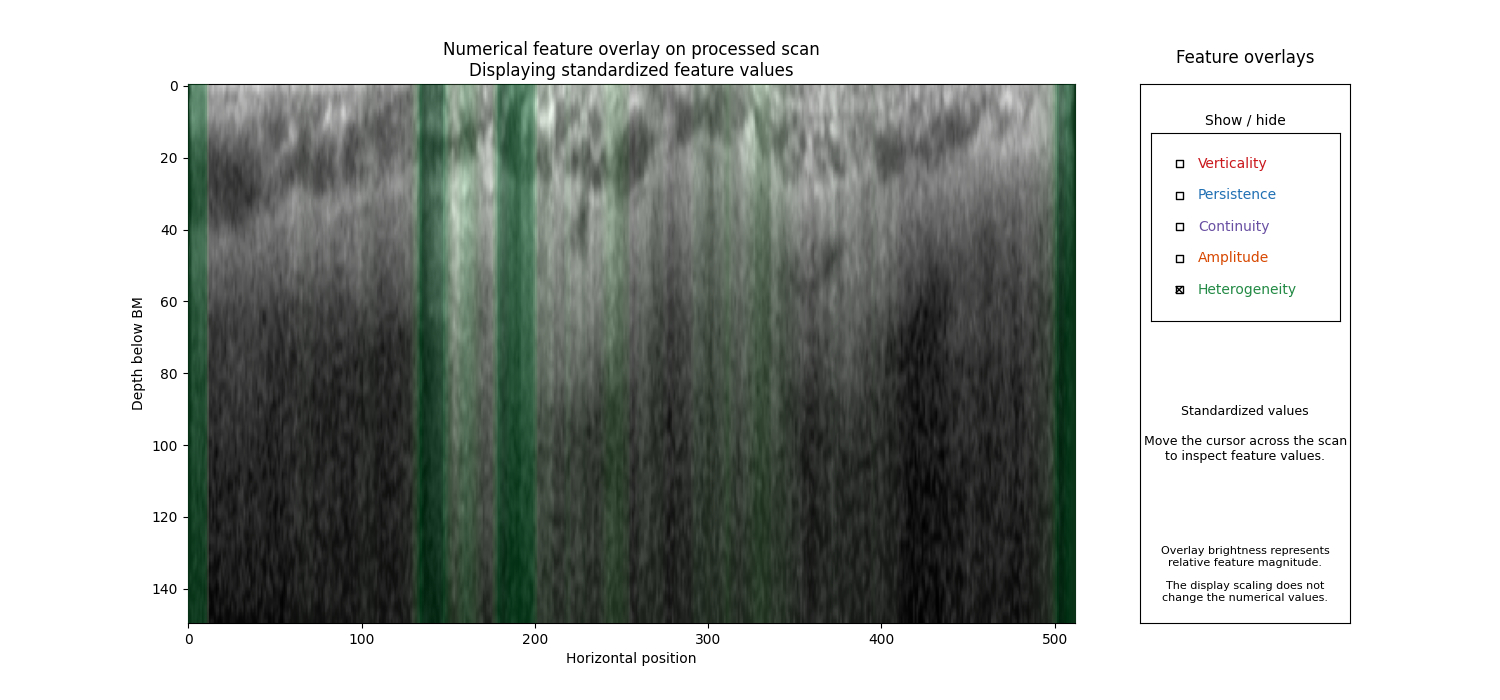

In [12]:
from src.detector.visualization import (
    create_feature_overlay_viewer,
)

feature_overlay_viewer = create_feature_overlay_viewer(
    image=result.denoised_scan,
    feature_result=feature_result,

    # Show standardized features because these are the values that
    # will later enter the weighted detector score.
    use_standardized=True,

    # Begin with only one feature visible to avoid overlapping colors.
    initially_visible=(
        "heterogeneity",
    ),

    maximum_alpha=0.50,
    display_percentiles=(
        2.0,
        98.0,
    ),
)

feature_overlay_viewer.show()

Five features appear to have plausible roles:

* Verticality: detects directionally vertical texture.
* Persistence: detects candidate signal extending through depth.
* Continuity: detects preservation of the horizontal pattern across depth.
* Amplitude: detects brighter hypertransmission regions.
* Heterogeneity: detects alternating or locally variable column intensity.

,verticality_standardized,persistence_standardized,continuity_standardized,amplitude_standardized,heterogeneity_standardized
verticality_standardized,1.000000,0.597191,0.916570,0.221349,0.877449
persistence_standardized,0.597191,1.000000,0.641756,0.823081,0.566462
continuity_standardized,0.916570,0.641756,1.000000,0.348901,0.920394
amplitude_standardized,0.221349,0.823081,0.348901,1.000000,0.311514
heterogeneity_standardized,0.877449,0.566462,0.920394,0.311514,1.000000


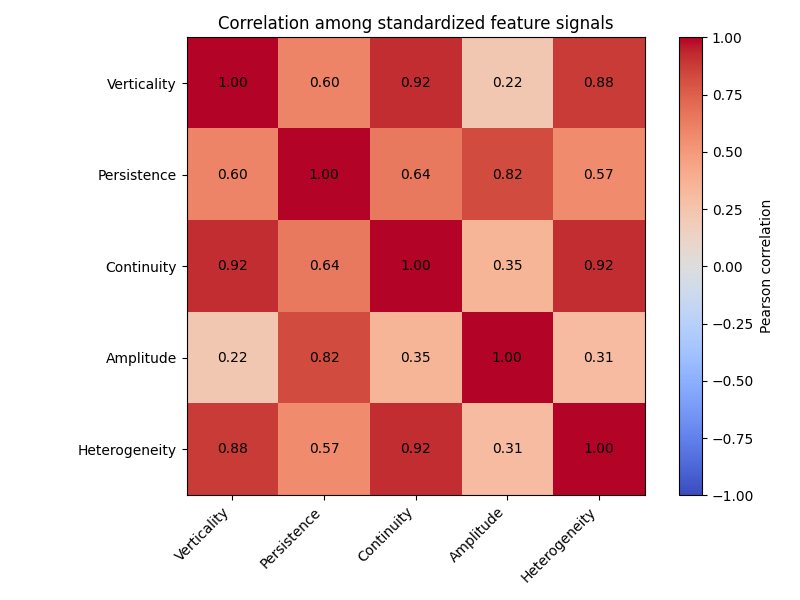

In [13]:
standardized_feature_df = feature_result.to_dataframe(
    include_standardized=True,
)

standardized_columns = [
    "verticality_standardized",
    "persistence_standardized",
    "continuity_standardized",
    "amplitude_standardized",
    "heterogeneity_standardized",
]

feature_correlation = standardized_feature_df[
    standardized_columns
].corr()

display(feature_correlation)

fig, axis = plt.subplots(
    figsize=(8, 6),
)

correlation_image = axis.imshow(
    feature_correlation.to_numpy(),
    vmin=-1.0,
    vmax=1.0,
    cmap="coolwarm",
)

axis.set_xticks(
    np.arange(
        len(standardized_columns)
    )
)

axis.set_yticks(
    np.arange(
        len(standardized_columns)
    )
)

axis.set_xticklabels(
    [
        "Verticality",
        "Persistence",
        "Continuity",
        "Amplitude",
        "Heterogeneity",
    ],
    rotation=45,
    ha="right",
)

axis.set_yticklabels(
    [
        "Verticality",
        "Persistence",
        "Continuity",
        "Amplitude",
        "Heterogeneity",
    ]
)

for row in range(
    feature_correlation.shape[0]
):
    for column in range(
        feature_correlation.shape[1]
    ):
        axis.text(
            column,
            row,
            f"{feature_correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

axis.set_title(
    "Correlation among standardized feature signals"
)

fig.colorbar(
    correlation_image,
    ax=axis,
    label="Pearson correlation",
)

plt.tight_layout()
plt.show()

# Barcoding Score

In [25]:
# Grouped
DETECTOR_CONFIG = {
    "scoring_mode": "grouped",

    # Initial proof-of-concept threshold.
    # This is not yet clinically tuned.
    "threshold": 0.0,

    # Within the structural group
    "structural_weights": {
        "verticality": 0.45,
        "continuity": 0.275,
        "heterogeneity": 0.275,
    },

    # Within the hypertransmission group
    "hypertransmission_weights": {
        "persistence": 0.55,
        "amplitude": 0.45,
    },

    # Between the two major evidence groups
    "group_weights": {
        "structural": 0.55,
        "hypertransmission": 0.45,
    },

    "normalize_weights": True,

    # Spatial cleanup
    "minimum_interval_length": 8,
    "maximum_gap_length": 4,

    # Half of a 21-pixel window when stride=1
    "edge_margin": 10,

    "cleanup_order": "fill_then_remove",
}

# Individual
INDIVIDUAL_DETECTOR_CONFIG = {
    "scoring_mode": "individual",
    "threshold": 1.0,

    "feature_weights": {
        "verticality": 0.25,
        "persistence": 0.25,
        "continuity": 0.15,
        "amplitude": 0.20,
        "heterogeneity": 0.15,
    },

    "normalize_weights": True,
    "minimum_interval_length": 8,
    "maximum_gap_length": 4,
    "edge_margin": 10,
    "cleanup_order": "fill_then_remove",
}

In [26]:
from src.detector.detector import (
    detect_barcoding,
)

detection_result = detect_barcoding(
    feature_result=feature_result,
    **DETECTOR_CONFIG,
)

print("Detection completed.")
print("Scoring mode:", detection_result.scoring_mode)
print("Threshold:", detection_result.threshold)
print("Number of positions:", detection_result.x_positions.size)
print("Raw positive positions:", detection_result.raw_mask.sum())
print("Cleaned positive positions:", detection_result.cleaned_mask.sum())
print("Detected intervals:", len(detection_result.intervals))

Detection completed.
Scoring mode: grouped
Threshold: 0.0
Number of positions: 512
Raw positive positions: 284
Cleaned positive positions: 255
Detected intervals: 2


In [27]:
from pprint import pprint

print(
    "Score range:",
    float(detection_result.score.min()),
    "to",
    float(detection_result.score.max()),
)

print(
    "Score mean:",
    float(detection_result.score.mean()),
)

print(
    "Score standard deviation:",
    float(detection_result.score.std()),
)

pprint(
    detection_result.metadata
)

Score range: -0.8705627918243408 to 1.8227899074554443
Score mean: 0.17212560772895813
Score standard deviation: 0.683700442314148
{'cleaned_positive_positions': 255,
 'cleanup': {'cleanup_order': 'fill_then_remove',
             'edge_margin': 10,
             'maximum_gap_length': 4,
             'minimum_interval_length': 8},
 'feature_window': {'padding_constant_value': 0.0,
                    'padding_mode': 'reflect',
                    'radius': 10,
                    'stride': 1,
                    'width': 21},
 'normalize_weights': True,
 'number_of_intervals': 2,
 'number_of_positions': 512,
 'raw_positive_positions': 284,
 'score_maximum': 1.8227899074554443,
 'score_mean': 0.17212560772895813,
 'score_minimum': -0.8705627918243408,
 'score_standard_deviation': 0.683700442314148,
 'scoring_mode': 'grouped',
 'threshold': 0.0,
 'weights': {'group_contributions': {'hypertransmission': array([-2.07069412e-01, -2.06359342e-01, -2.08319291e-01, -2.09748209e-01,
       -2.177

In [28]:
if detection_result.intervals:
    for interval_number, interval in enumerate(
        detection_result.intervals,
        start=1,
    ):
        print(
            f"{interval_number:02d}. "
            f"x={interval.x_start:.1f}–{interval.x_end:.1f}, "
            f"width={interval.width_pixels:.1f} px, "
            f"mean score={interval.mean_score:.3f}, "
            f"max score={interval.maximum_score:.3f}"
        )
else:
    print("No intervals exceeded the current threshold.")

01. x=129.0–275.0, width=147.0 px, mean score=0.961, max score=1.823
02. x=289.0–396.0, width=108.0 px, mean score=0.316, max score=0.878


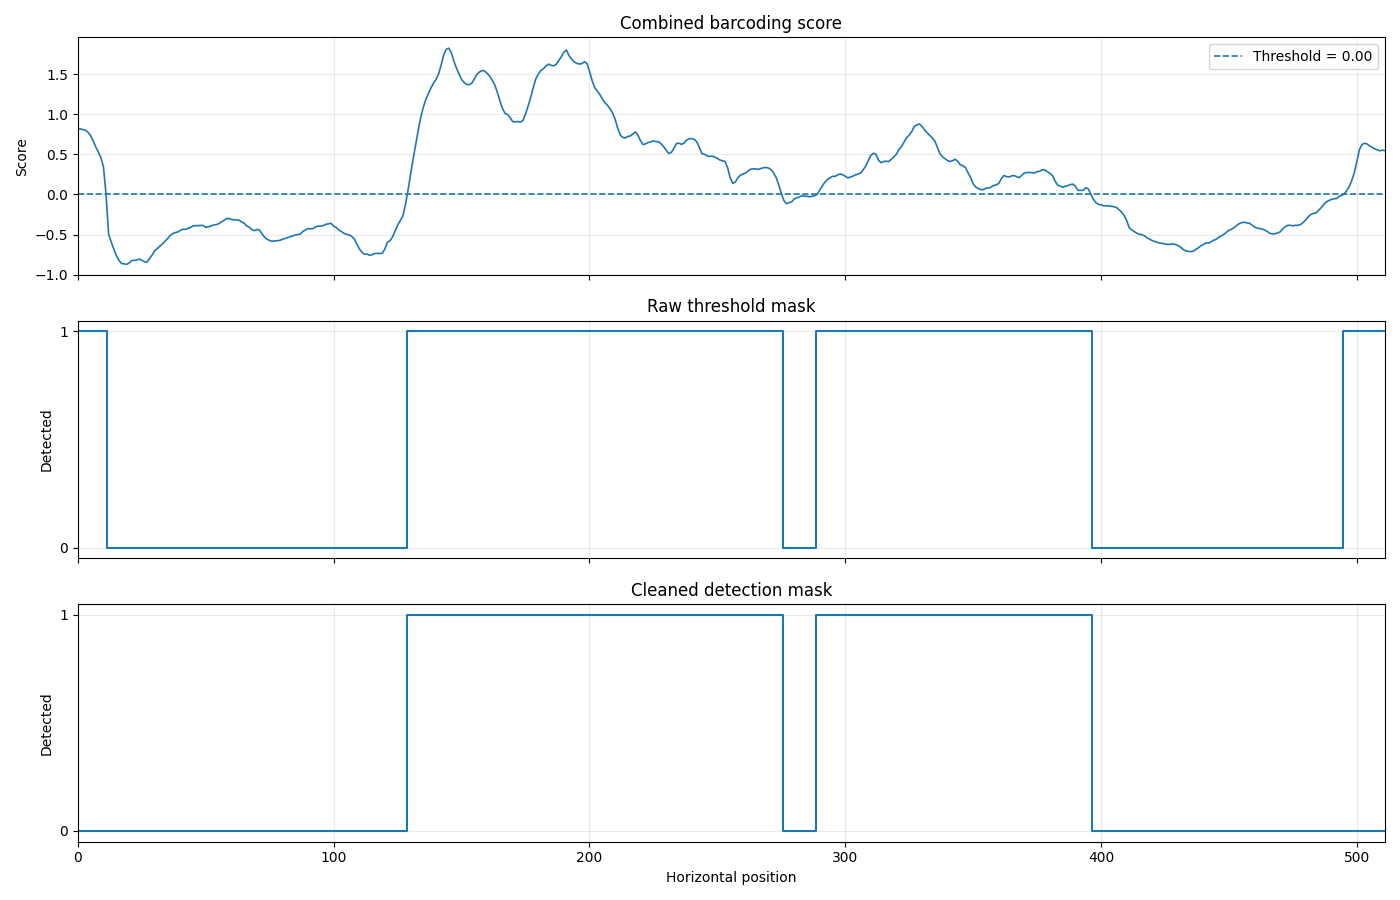

In [29]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True,
)

axes[0].plot(
    detection_result.x_positions,
    detection_result.score,
    linewidth=1.2,
)

axes[0].axhline(
    detection_result.threshold,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"Threshold = "
        f"{detection_result.threshold:.2f}"
    ),
)

axes[0].set_title(
    "Combined barcoding score"
)

axes[0].set_ylabel(
    "Score"
)

axes[0].legend()
axes[0].grid(
    alpha=0.25
)

axes[1].step(
    detection_result.x_positions,
    detection_result.raw_mask.astype(int),
    where="mid",
)

axes[1].set_title(
    "Raw threshold mask"
)

axes[1].set_ylabel(
    "Detected"
)

axes[1].set_yticks(
    [0, 1]
)

axes[1].grid(
    alpha=0.25
)

axes[2].step(
    detection_result.x_positions,
    detection_result.cleaned_mask.astype(int),
    where="mid",
)

axes[2].set_title(
    "Cleaned detection mask"
)

axes[2].set_xlabel(
    "Horizontal position"
)

axes[2].set_ylabel(
    "Detected"
)

axes[2].set_yticks(
    [0, 1]
)

axes[2].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

axes[2].grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

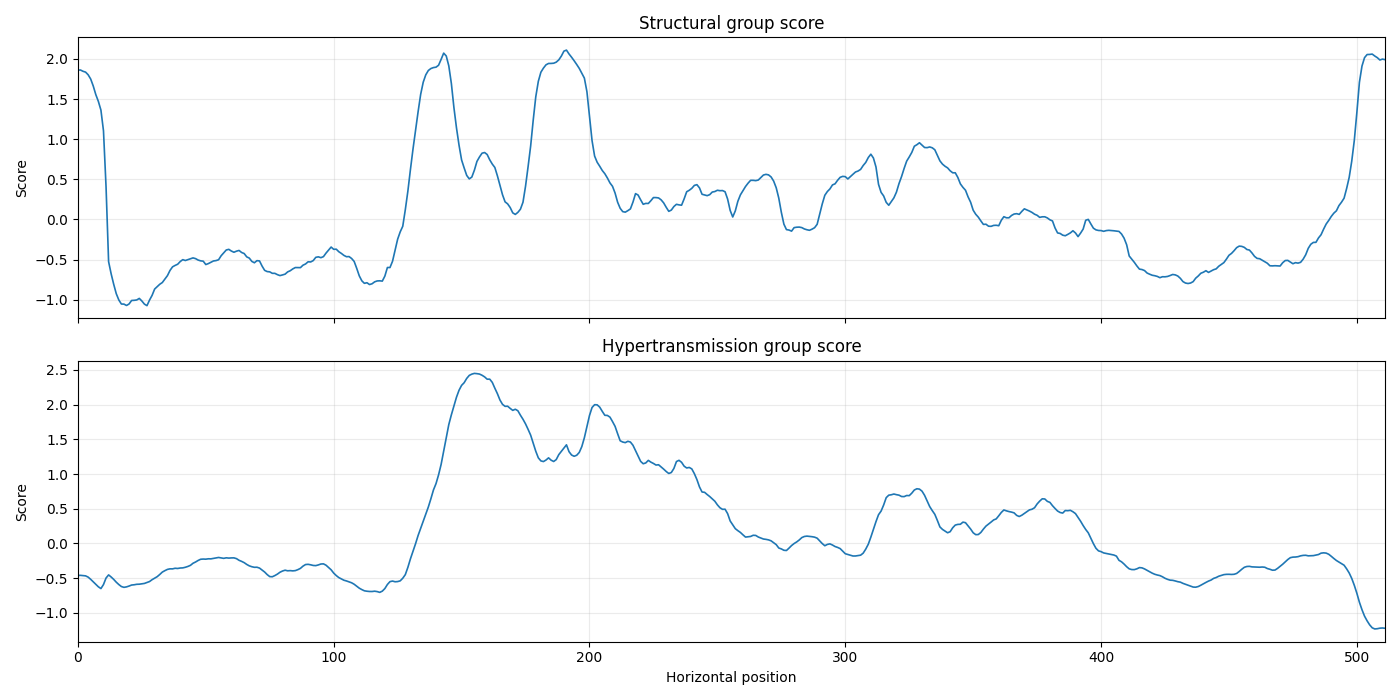

In [30]:
if detection_result.group_scores:
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 7),
        sharex=True,
    )

    axes[0].plot(
        detection_result.x_positions,
        detection_result.group_scores[
            "structural"
        ],
        linewidth=1.2,
    )

    axes[0].set_title(
        "Structural group score"
    )

    axes[0].set_ylabel(
        "Score"
    )

    axes[0].grid(
        alpha=0.25
    )

    axes[1].plot(
        detection_result.x_positions,
        detection_result.group_scores[
            "hypertransmission"
        ],
        linewidth=1.2,
    )

    axes[1].set_title(
        "Hypertransmission group score"
    )

    axes[1].set_xlabel(
        "Horizontal position"
    )

    axes[1].set_ylabel(
        "Score"
    )

    axes[1].set_xlim(
        0,
        result.denoised_scan.shape[1] - 1,
    )

    axes[1].grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

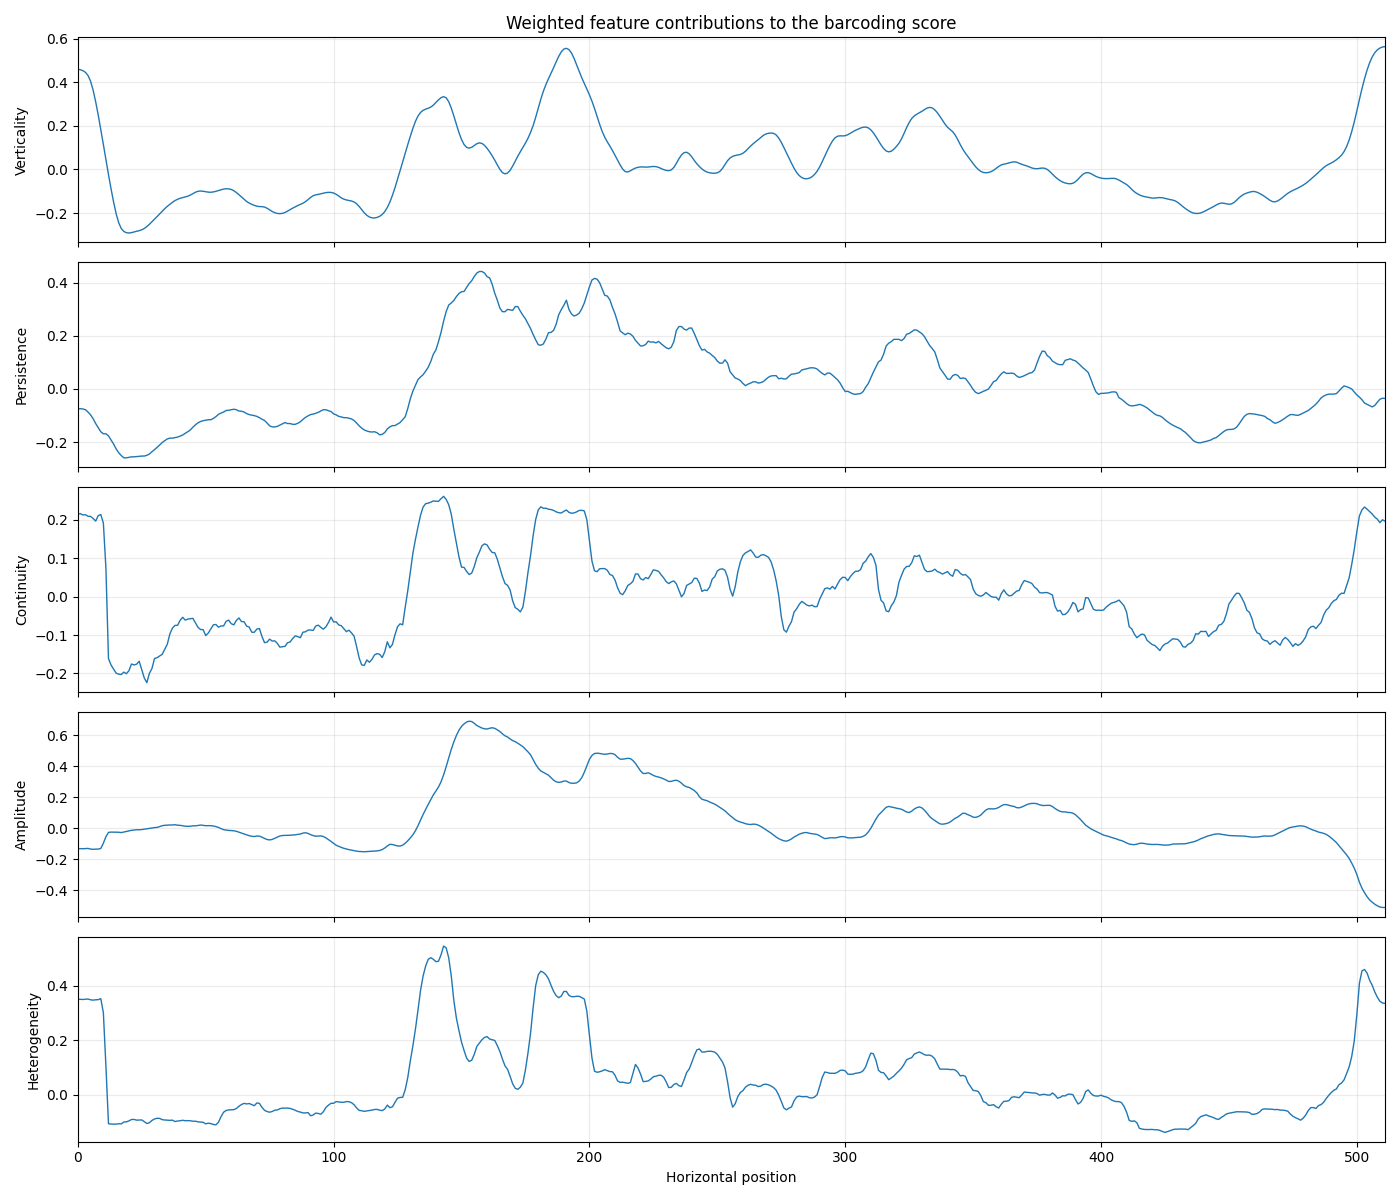

In [31]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(14, 12),
    sharex=True,
)

for axis, feature_name in zip(
    axes,
    (
        "verticality",
        "persistence",
        "continuity",
        "amplitude",
        "heterogeneity",
    ),
):
    axis.plot(
        detection_result.x_positions,
        detection_result.feature_contributions[
            feature_name
        ],
        linewidth=1.0,
    )

    axis.set_ylabel(
        feature_name.title()
    )

    axis.grid(
        alpha=0.25
    )

axes[0].set_title(
    "Weighted feature contributions to the barcoding score"
)

axes[-1].set_xlabel(
    "Horizontal position"
)

axes[-1].set_xlim(
    0,
    result.denoised_scan.shape[1] - 1,
)

plt.tight_layout()
plt.show()

## Mixed vs Individual Scoring

In [32]:
individual_detection_result = detect_barcoding(
    feature_result=feature_result,
    **INDIVIDUAL_DETECTOR_CONFIG,
)

print(
    "Grouped intervals:",
    len(detection_result.intervals),
)

print(
    "Individual intervals:",
    len(individual_detection_result.intervals),
)

Grouped intervals: 2
Individual intervals: 2


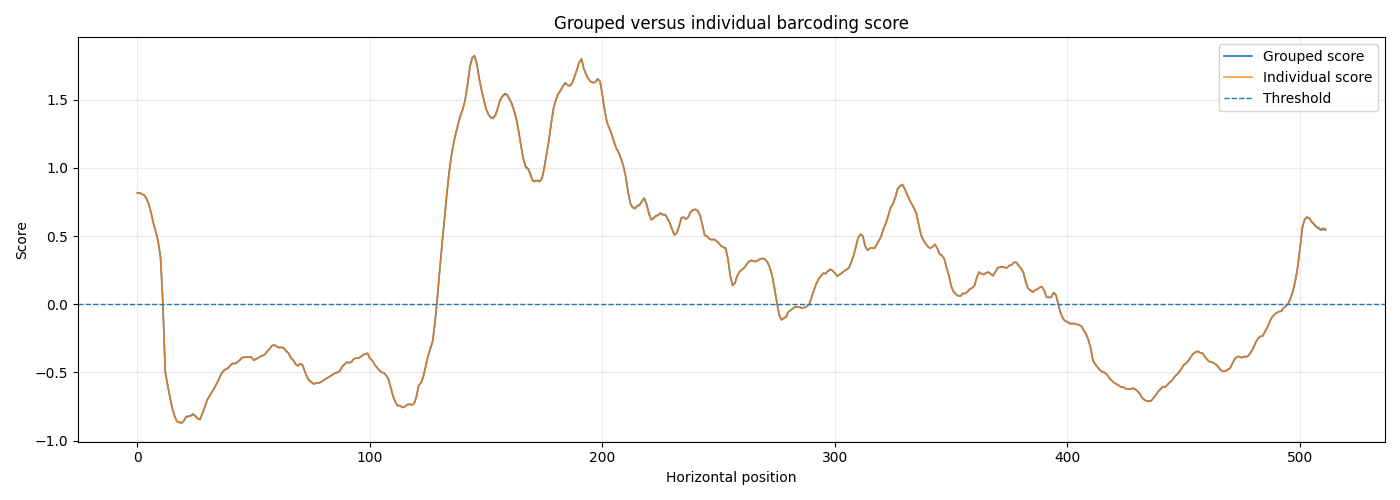

In [33]:
plt.figure(
    figsize=(14, 5)
)

plt.plot(
    detection_result.x_positions,
    detection_result.score,
    label="Grouped score",
    linewidth=1.2,
)

plt.plot(
    individual_detection_result.x_positions,
    individual_detection_result.score,
    label="Individual score",
    linewidth=1.2,
    alpha=0.8,
)

plt.axhline(
    DETECTOR_CONFIG["threshold"],
    linestyle="--",
    linewidth=1.0,
    label="Threshold",
)

plt.title(
    "Grouped versus individual barcoding score"
)

plt.xlabel(
    "Horizontal position"
)

plt.ylabel(
    "Score"
)

plt.legend()
plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [34]:
%matplotlib widget

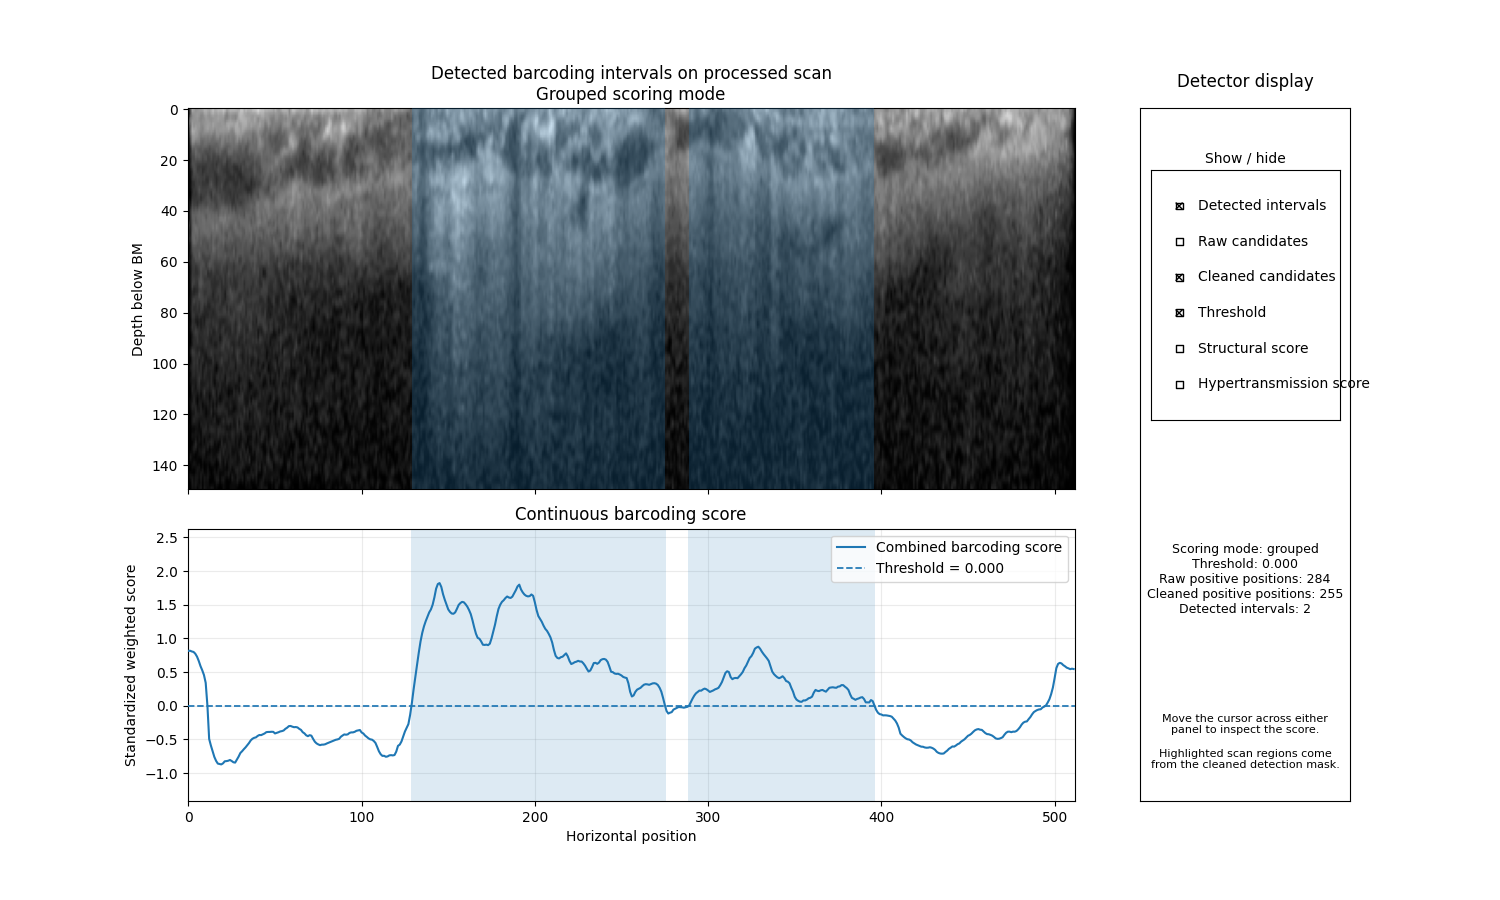

In [35]:
from src.detector.visualization import (
    create_barcode_score_viewer,
)

barcode_score_viewer = create_barcode_score_viewer(
    image=result.denoised_scan,
    detection_result=detection_result,

    initially_visible=(
        "detected_intervals",
        "cleaned_candidates",
        "threshold",
    ),

    interval_alpha=0.25,
    candidate_alpha=0.15,

    # Use None for automatic y-axis limits.
    score_limits=None,

    figure_size=(15, 9),
)

barcode_score_viewer.show()

In [ ]:
# TODO: Characterize EA and Vessel regions
# TODO: Tune Weights
# TODO: Run on other volumes and other patiets
# TODO: use logistic regression to estimate weights for each score component

## Batch Process Test: All Scans Per Volume

We apply this automated detector to all scans of a single volume. We are not doing numerical summaries now, just visualizations

In [ ]:
VOLUME_NUMBER = 8
SCAN_NUMBER = 48

matching_records = [
    registry_record
    for registry_record in registry
    if int(registry_record.subject_id) == VOLUME_NUMBER
]

if not matching_records:
    raise KeyError(
        f"Volume {VOLUME_NUMBER} was not found in the registry."
    )

selected_volume_record = matching_records[0]

selected_volume = load_e2e_volume(
    selected_volume_record.e2e_path
)

if not 0 <= SCAN_NUMBER < len(selected_volume):
    raise IndexError(
        f"SCAN_NUMBER={SCAN_NUMBER} is outside the valid range "
        f"0 to {len(selected_volume) - 1} for volume "
        f"{VOLUME_NUMBER}."
    )

In [ ]:
selected_processed = preprocess_bscan(
    volume=selected_volume,
    bscan_index=SCAN_NUMBER,
    **PREPROCESSING_CONFIG,
)

selected_features = extract_feature_signals(
    image=selected_processed.denoised_scan,
    **FEATURE_CONFIG,
)

selected_detection = detect_barcoding(
    feature_result=selected_features,
    **DETECTOR_CONFIG,
)

selected_scan_viewer = create_barcode_score_viewer(
    image=selected_processed.denoised_scan,
    detection_result=selected_detection,
    initially_visible=(
        "detected_intervals",
    ),
    interval_alpha=0.30,
    candidate_alpha=0.15,
    score_limits=None,
    figure_size=(15, 9),
)

selected_scan_viewer.show()

## Batch Process Test: $n$-Scans Per Progression Group

We apply this automated detector to select scans of all volumes. We are not doing numerical summaries now, just visualizations

In [ ]:
SELECTED_SCAN_CONFIG = {
    "fast": {
        8: 48,
        9: 48,
        12: 48,
        41: 48,
        49: 48,
    },
    "slow": {
        17: 48,
        23: 48,
        35: 48,
        36: 48,
        47: 48,
    },
}

selected_scan_runs = {}

for progression_group, subject_scans in (
    SELECTED_SCAN_CONFIG.items()
):
    for subject_id, bscan_index in subject_scans.items():
        matching_records = [
            registry_record
            for registry_record in registry
            if (
                int(registry_record.subject_id)
                == int(subject_id)
                and str(
                    registry_record.progression_group
                ).lower()
                == progression_group.lower()
            )
        ]

        if not matching_records:
            raise KeyError(
                f"Subject {subject_id} in group "
                f"'{progression_group}' was not found."
            )

        current_record = matching_records[0]

        current_volume = load_e2e_volume(
            current_record.e2e_path
        )

        if not 0 <= bscan_index < len(current_volume):
            raise IndexError(
                f"Configured B-scan {bscan_index} is outside "
                f"the valid range 0 to {len(current_volume) - 1} "
                f"for subject {subject_id}."
            )

        current_processed = preprocess_bscan(
            volume=current_volume,
            bscan_index=bscan_index,
            **PREPROCESSING_CONFIG,
        )

        current_features = extract_feature_signals(
            image=current_processed.denoised_scan,
            **FEATURE_CONFIG,
        )

        current_detection = detect_barcoding(
            feature_result=current_features,
            **DETECTOR_CONFIG,
        )

        selected_scan_runs[
            (
                progression_group,
                subject_id,
            )
        ] = {
            "record": current_record,
            "bscan_index": int(bscan_index),
            "processed": current_processed,
            "features": current_features,
            "detection": current_detection,
        }

In [ ]:
DISPLAY_GROUP = "fast"

def plot_progression_group_intervals(
    selected_scan_runs: dict,
    progression_group: str,
    *,
    figure_size: tuple[float, float] = (15, 14),
    interval_color: str = "tab:red",
    interval_alpha: float = 0.30,
    columns: int = 1,
):
    """
    Display all configured scans from one progression group.

    Each panel contains only:
    - the denoised, preprocessed scan;
    - shaded cleaned barcoding intervals.

    Parameters
    ----------
    selected_scan_runs:
        Dictionary created by the configured-scan processing cell. Keys
        must have the form ``(progression_group, subject_id)``.
    progression_group:
        Group to display, such as ``"fast"`` or ``"slow"``.
    figure_size:
        Matplotlib figure size.
    interval_color:
        Color used for detected interval overlays.
    interval_alpha:
        Transparency of detected interval overlays.
    columns:
        Number of subplot columns. Use 1 for vertically stacked scans or
        2 for a more compact arrangement.

    Returns
    -------
    figure:
        Matplotlib figure.
    axes:
        Array of subplot axes.
    """
    resolved_group = str(
        progression_group
    ).strip().lower()

    matching_runs = [
        (
            int(subject_id),
            run,
        )
        for (
            group_name,
            subject_id,
        ), run in selected_scan_runs.items()
        if str(
            group_name
        ).strip().lower()
        == resolved_group
    ]

    if not matching_runs:
        raise KeyError(
            f"No completed detector runs were found for "
            f"group '{progression_group}'."
        )

    matching_runs.sort(
        key=lambda item: item[0]
    )

    number_of_scans = len(
        matching_runs
    )

    if columns <= 0:
        raise ValueError(
            "columns must be positive."
        )

    rows = int(
        np.ceil(
            number_of_scans
            / columns
        )
    )

    figure, axes = plt.subplots(
        nrows=rows,
        ncols=columns,
        figsize=figure_size,
        squeeze=False,
    )

    flat_axes = axes.ravel()

    for axis, (
        subject_id,
        run,
    ) in zip(
        flat_axes,
        matching_runs,
    ):
        image = (
            run["processed"]
            .denoised_scan
        )

        detection = run[
            "detection"
        ]

        bscan_index = int(
            run["bscan_index"]
        )

        image_height, image_width = (
            image.shape
        )

        axis.imshow(
            image,
            cmap="gray",
            aspect="auto",
            extent=(
                -0.5,
                image_width - 0.5,
                image_height - 0.5,
                -0.5,
            ),
        )

        for interval in detection.intervals:
            axis.axvspan(
                interval.x_start,
                interval.x_end,
                color=interval_color,
                alpha=interval_alpha,
                linewidth=0,
            )

        axis.set_title(
            f"Subject {subject_id} | "
            f"{resolved_group.title()} progressor | "
            f"B-scan {bscan_index}"
        )

        axis.set_xlim(
            -0.5,
            image_width - 0.5,
        )

        axis.set_ylim(
            image_height - 0.5,
            -0.5,
        )

        axis.set_xlabel(
            "Horizontal position"
        )

        axis.set_ylabel(
            "Depth below BM"
        )

    for unused_axis in flat_axes[
        number_of_scans:
    ]:
        unused_axis.set_visible(
            False
        )

    figure.suptitle(
        f"{resolved_group.title()} progressors: "
        "detected barcoding intervals",
        fontsize=16,
        y=1.01,
    )

    figure.tight_layout()

    return figure, axes

group_figure, group_axes = (
    plot_progression_group_intervals(
        selected_scan_runs=selected_scan_runs,
        progression_group=DISPLAY_GROUP,
        figure_size=(15, 16),
        interval_color="tab:red",
        interval_alpha=0.30,
        columns=1,
    )
)

plt.show()